### This notebook is reformed, the first part is from an old analysis of empirical p-values, the second is a new one using t to z conversion (for plots sake), stouffer method for p val aggregation, maybe add it to fisher

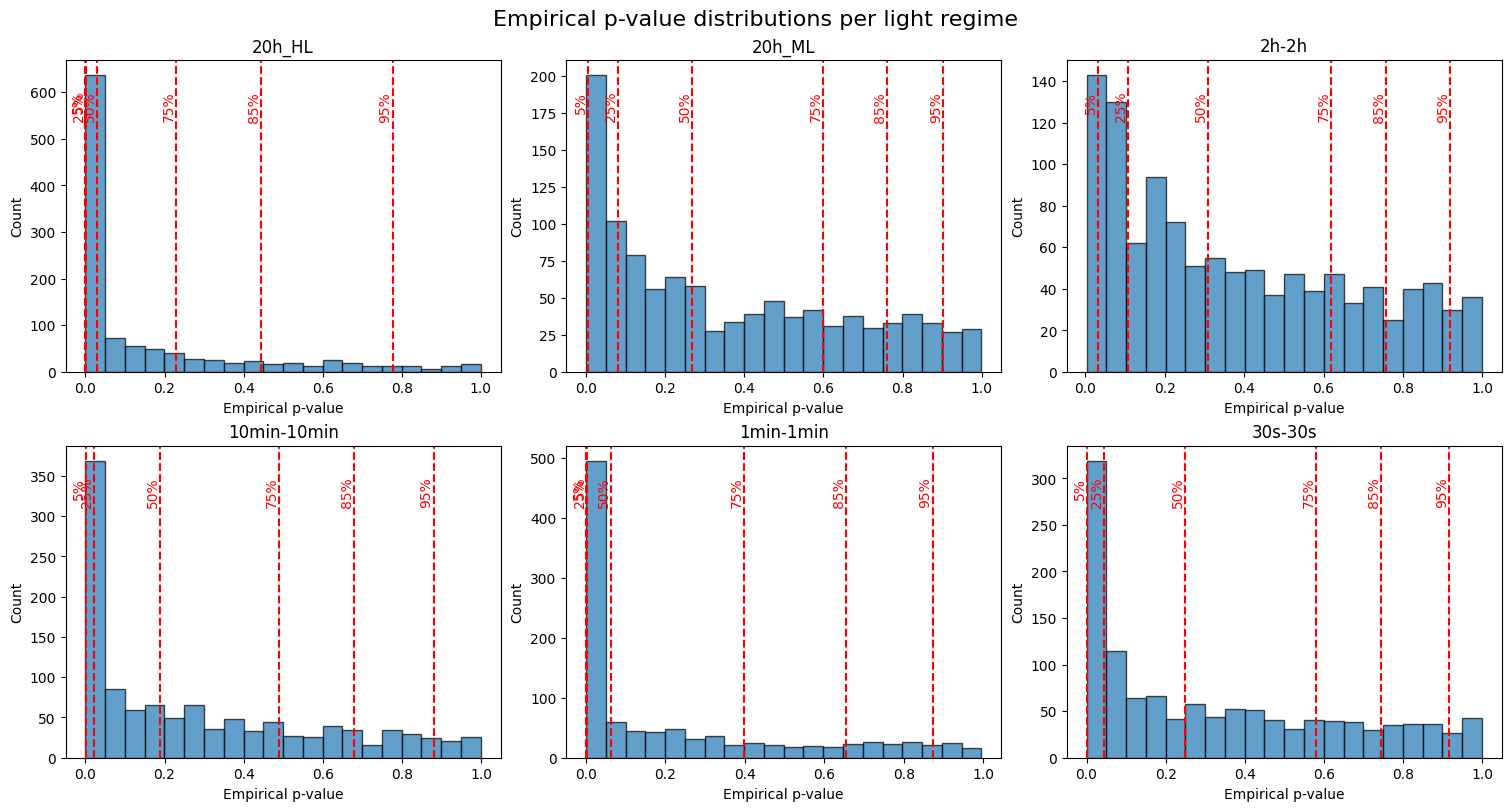

In [14]:
import matplotlib.pyplot as plt
import numpy as np

light_regimes = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '1min-1min', '30s-30s']
n = len(light_regimes)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4), constrained_layout=True)
axes = axes.flatten()

for i, light in enumerate(light_regimes):
    ax = axes[i]
    pvals = empirical_pvals_df[empirical_pvals_df['light_regime'] == light]['empirical_p_value'].dropna()

    ax.hist(pvals, bins=20, edgecolor='black', alpha=0.7)
    ax.set_title(light)
    ax.set_xlabel('Empirical p-value')
    ax.set_ylabel('Count')

    for q in [5, 25, 50, 75, 85, 95]:
        perc = np.percentile(pvals, q)
        ax.axvline(perc, color='red', linestyle='--')
        ax.text(perc, ax.get_ylim()[1]*0.9, f'{q}%', rotation=90, color='red', va='top', ha='right')

# Supprimer les cases vides si le nombre de régimes est < 9
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Empirical p-value distributions per light regime', fontsize=16)
plt.show()


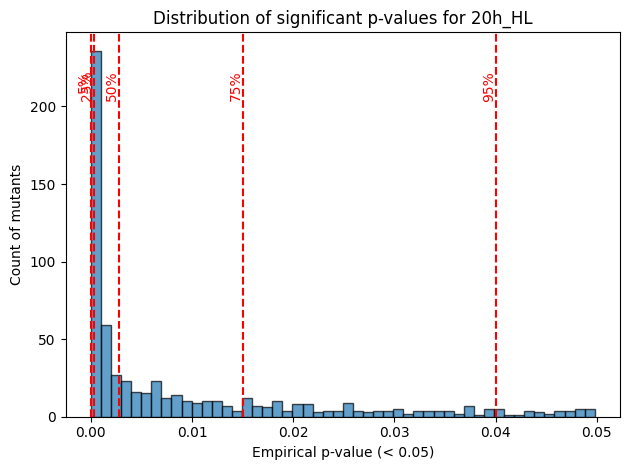

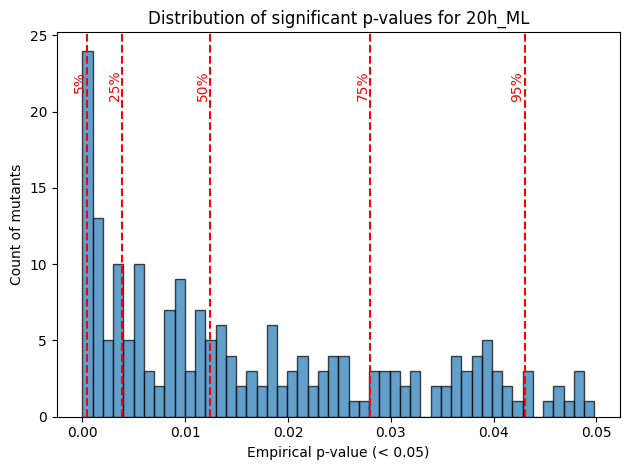

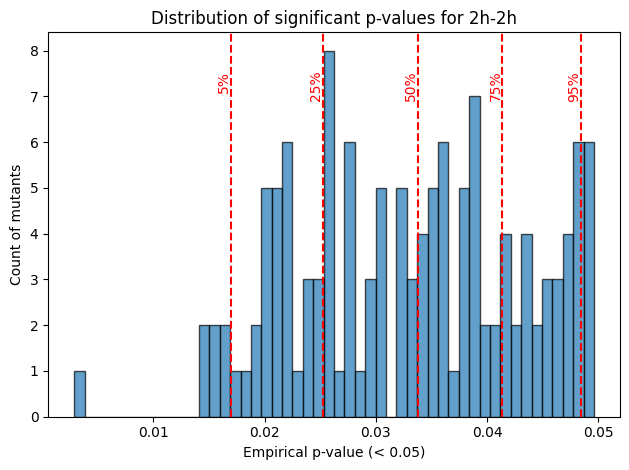

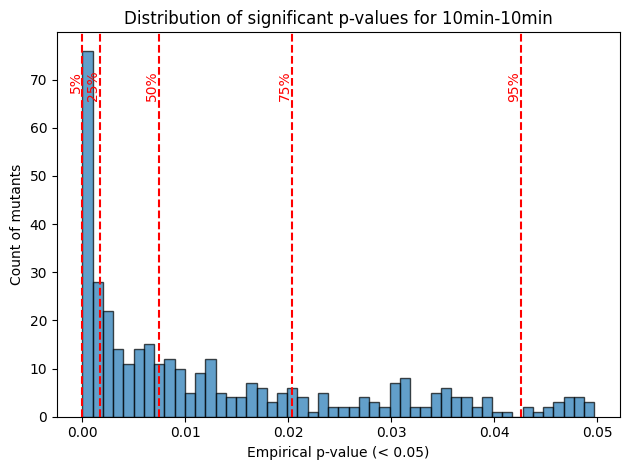

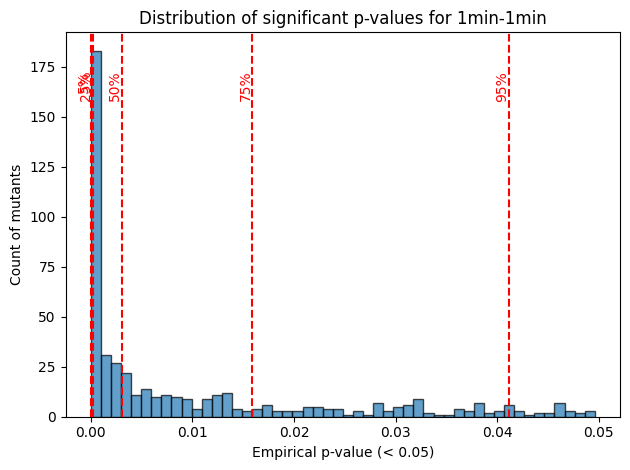

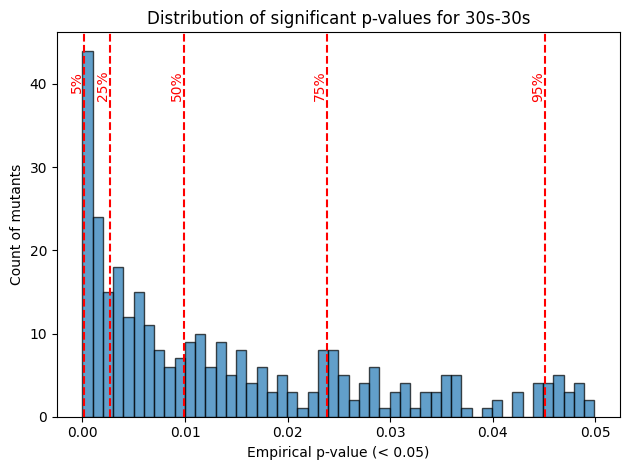

In [15]:
import matplotlib.pyplot as plt
import numpy as np

light_regimes = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '1min-1min', '30s-30s']

for light in light_regimes:
    # Filter for p-values < 0.05
    pvals = empirical_pvals_df[
        (empirical_pvals_df['light_regime'] == light) &
        (empirical_pvals_df['empirical_p_value'] < 0.05)
    ]['empirical_p_value']

    if pvals.empty:
        print(f"No p-values < 0.05 for {light}")
        continue

    # Plot histogram with more bins
    plt.hist(pvals, bins=50, edgecolor='black', alpha=0.7)
    plt.xlabel('Empirical p-value (< 0.05)')
    plt.ylabel('Count of mutants')
    plt.title(f'Distribution of significant p-values for {light}')

    # Add percentile lines
    for q in [5, 25, 50, 75, 95]:
        perc = np.percentile(pvals, q)
        plt.axvline(perc, color='red', linestyle='--')
        plt.text(perc, plt.ylim()[1]*0.9, f'{q}%', rotation=90, color='red', va='top', ha='right')

    plt.tight_layout()
    plt.show()


In [ ]:
# empirical_pvals_df.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/empirical_pvals_PHASE2.csv', index=False)

## 1 p value per gene (pooled/absolute)

Group 1: all WT slopes under that light regime

Group 2: all individual slopes from all mutant_IDs belonging to that gene across all plates under the same light regime

So you do a 2-sample t-test between:

mutated_genes == gene

mutated_genes startswith WT

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

# === Load data ===
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2_light_status_slope.csv')

# === Clean ===
data = data[data['mutated_genes'].notna() & data['y2_slope'].notna()]
data['plate'] = data['plate'].astype(str)

light_regimes = ['20h_HL', '20h_ML', '2h-2h', '10min-10min','5min-5min', '1min-5min', '1min-1min', '30s-30s']

results = []

for regime in light_regimes:
    regime_data = data[data['light_regime'] == regime]
    
    # WT group (all plates)
    wt_slopes = regime_data[regime_data['mutated_genes'].str.startswith('WT')]['y2_slope'].dropna()
    if len(wt_slopes) < 2:
        continue
    
    for gene, group in regime_data[~regime_data['mutated_genes'].str.startswith('WT')].groupby('mutated_genes'):
        mut_slopes = group['y2_slope'].dropna()
        if len(mut_slopes) < 2:
            continue
        
        t_stat, p_val = ttest_ind(mut_slopes, wt_slopes, equal_var=False)

        results.append({
            'mutated_genes': gene,
            'light_regime': regime,
            'n_mutant_slopes': len(mut_slopes),
            'n_wt_slopes': len(wt_slopes),
            'mut_mean': mut_slopes.mean(),
            'wt_mean': wt_slopes.mean(),
            't_stat': t_stat,
            'p_value': p_val
        })

# === Make dataframe ===
gene_regime_df = pd.DataFrame(results)
gene_regime_df['FDR'] = multipletests(gene_regime_df['p_value'], method='fdr_bh')[1]

# === Save ===
gene_regime_df.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/gene_level_ttest_pooled.csv', index=False)


/tmp/ipykernel_357122/4059943536.py:7: DtypeWarning: Columns (2,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,373,374,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2_light_status_slope.csv')


# gene two sample test, WT distrib vs gene per plate (1 p value per gene per plate), just for the visualistaion sake

Group 1: all WT slopes on that plate and light regime

Group 2: average slope for each mutant_ID belonging to that gene on that plate and light regime

In [67]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

# Load and clean
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2_light_status_slope.csv')
data = data[~(data['plate'].astype(str).str.contains('33', na=False))]
data = data[data['mutated_genes'].notna() & data['y2_slope'].notna()]
data['plate'] = data['plate'].astype(str)
data['big_plate'] = data['plate'].str.split('v').str[0]

light_regimes = ['20h_HL', '20h_ML', '2h-2h', '10min-10min','5min-5min', '1min-5min', '1min-1min', '30s-30s']

results = []

for regime in light_regimes:
    regime_data = data[data['light_regime'] == regime]

    for (gene, big_plate), group in regime_data[~regime_data['mutated_genes'].str.startswith('WT')].groupby(['mutated_genes', 'big_plate']):
        
        # Mutant means: average across replicates for each mutant_ID
        mutant_means = (
            group.groupby('mutant_ID')['y2_slope']
            .mean()
            .reset_index(name='slope')
        )

        if len(mutant_means) < 2:
            continue

        # WT means: average across same well_id across v1/v2/v3 of the big_plate
        wt_group = regime_data[
            (regime_data['big_plate'] == big_plate) &
            (regime_data['mutated_genes'].str.startswith('WT'))
        ]

        if 'well_id' not in wt_group.columns:
            raise ValueError("You must have a 'well_id' column to average WT by well position.")

        wt_means = (
            wt_group.groupby('well_id')['y2_slope']
            .mean()
            .reset_index(name='slope')
        )

        if len(wt_means) < 2:
            continue

        # Welch t-test
        t_stat, p_val = ttest_ind(mutant_means['slope'], wt_means['slope'], equal_var=False)

        results.append({
            'mutated_genes': gene,
            'big_plate': big_plate,
            'light_regime': regime,
            'n_mutants': len(mutant_means),
            'n_wts': len(wt_means),
            'mut_mean': mutant_means['slope'].mean(),
            'wt_mean': wt_means['slope'].mean(),
            't_stat': t_stat,
            'p_value': p_val
        })

# Compile results
df = pd.DataFrame(results)
df['FDR'] = multipletests(df['p_value'], method='fdr_bh')[1]

df.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/gene_level_ttest_by_bigplate_balanced.csv', index=False)

/tmp/ipykernel_357122/1176417179.py:7: DtypeWarning: Columns (2,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,373,374,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2_light_status_slope.csv')


### Mutant z scores and stouffer analyis

focus rn only on phase 2 and then we'll 

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_1samp, norm
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt

data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2_light_status_slope.csv')
data=data[~(data['plate'].astype(str).str.contains('33', na=False))]
#data['y2_slope'] ==data['y2_slope_mixed_centered']
def mutant_level_pvals(mutants_df, wt_df, regime):
    records = []
    mut_sub = mutants_df[mutants_df['light_regime'] == regime]
    wt_sub = wt_df[wt_df['light_regime'] == regime]  #change this line to determine if wts on same plate or all wts
    
    for _, row in mut_sub.iterrows():
        mutant_id = row['mutant_ID']
        gene = row['mutated_genes']
        plate = row['plate']
        mutant_slope = row['y2_slope']
        wt_slopes = wt_sub['y2_slope'].values
        
        if len(wt_slopes) < 2:
            continue
        
        t_stat, p_val = ttest_1samp(wt_slopes, popmean=mutant_slope)  #1sample t test if the mean of wts is statistically different from the 1 mutant value
        p_val = max(p_val, 1e-300)
        z = np.sign(np.mean(wt_slopes) - mutant_slope) * norm.ppf(1 - p_val/2)
        
        records.append({
            'mutant_ID': mutant_id,
            'mutated_genes': gene,
            'y2_slope': mutant_slope,
            'plate': plate,
            'light_regime': regime,
            'p_value': p_val,
            'z_score': z
        })
        
    return pd.DataFrame(records)
def gene_level_stouffer(mutant_plate_df):
    mutant_counts = mutant_plate_df.groupby('mutant_ID').size().to_dict()
    
    gene_records = []
    for gene, group in mutant_plate_df.groupby('mutated_genes'):
        pvals = group['p_value'].values
        zscores = group['z_score'].values
        weights = 1/group['mutant_ID'].map(mutant_counts).values
        
        #weighted_z = np.sum(weights * zscores) / np.sqrt(np.sum(weights**2))
        weighted_z = np.sum(zscores) / np.sqrt(len(zscores))
        combined_p = 2 * norm.sf(abs(weighted_z))
        
        gene_records.append({
            'gene': gene,
            'combined_z': weighted_z,
            'combined_p': combined_p
        })
    
    gene_df = pd.DataFrame(gene_records)
    _, fdr_pvals, _, _ = multipletests(gene_df['combined_p'], method='fdr_bh')
    gene_df['FDR_p_value'] = fdr_pvals
    
    return gene_df

light_regimes = ['20h_HL', '20h_ML', '2h-2h', '10min-10min','5min-5min', '1min-5min', '1min-1min', '30s-30s']

all_mutant_results = []
all_gene_results = []
for regime in light_regimes:

    wt_df = data[data['mutated_genes'].notna() & data['mutated_genes'].str.startswith('WT')]

    mutants_df = data[data['mutated_genes'].notna() & ~data['mutated_genes'].str.startswith('WT').fillna(False)]
    
    print(f"\n{regime}: processing...")
    mutant_df = mutant_level_pvals(mutants_df, wt_df, regime)
    all_mutant_results.append(mutant_df)

    gene_df = gene_level_stouffer(mutant_df)
    gene_df['light_regime'] = regime
    all_gene_results.append(gene_df)

# Concatenate all results into one dataframe
gene_level_df = pd.concat(all_gene_results, ignore_index=True)  #change to all_mutant to see mut res
mutant_level_df = pd.concat(all_mutant_results, ignore_index=True)

mutant_level_df.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2_p-to-zconversion.csv', index=False)
#full_df.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2_p-to-zconversion.csv', index=False)

# Plot overall p-value distribution
# plt.figure(figsize=(6,4))
# plt.hist(full_df['combined_p'], bins=30, color='skyblue', edgecolor='black')
# plt.title("All regimes: gene-level p-value distribution")
# plt.show()

# Save full result in one file
#full_df.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Quantile_normalization/all_genelevel_stouffer_results_rawslopes.csv', index=False)


In [87]:
full_df = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/gene_level_ttest_pooled.csv')
full_df = full_df[full_df['FDR'] < 0.05]
data = full_df
data_clean = data[~data['mutated_genes'].isna() & ~data['light_regime'].isna()]

gene_counts = data_clean.groupby('light_regime')['mutated_genes'].nunique().reset_index()

gene_counts.columns = ['light_regime', 'unique_gene_count']

print(gene_counts)
full_df.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/DifferentTestGenes3/all_genelevel_stouffer_results_FDR05_rawslopes_phase1.csv', index=False)

  light_regime  unique_gene_count
0  10min-10min                 55
1    1min-1min                298
2    1min-5min                163
3       20h_HL                 70
4       20h_ML                120
5        2h-2h                153
6      30s-30s                334
7    5min-5min                249


/tmp/ipykernel_357122/1360471681.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['combined_p'] = filtered_df['FDR']
/tmp/ipykernel_357122/1360471681.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['combined_z'] = filtered_df['t_stat']
/tmp/ipykernel_357122/1360471681.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.p

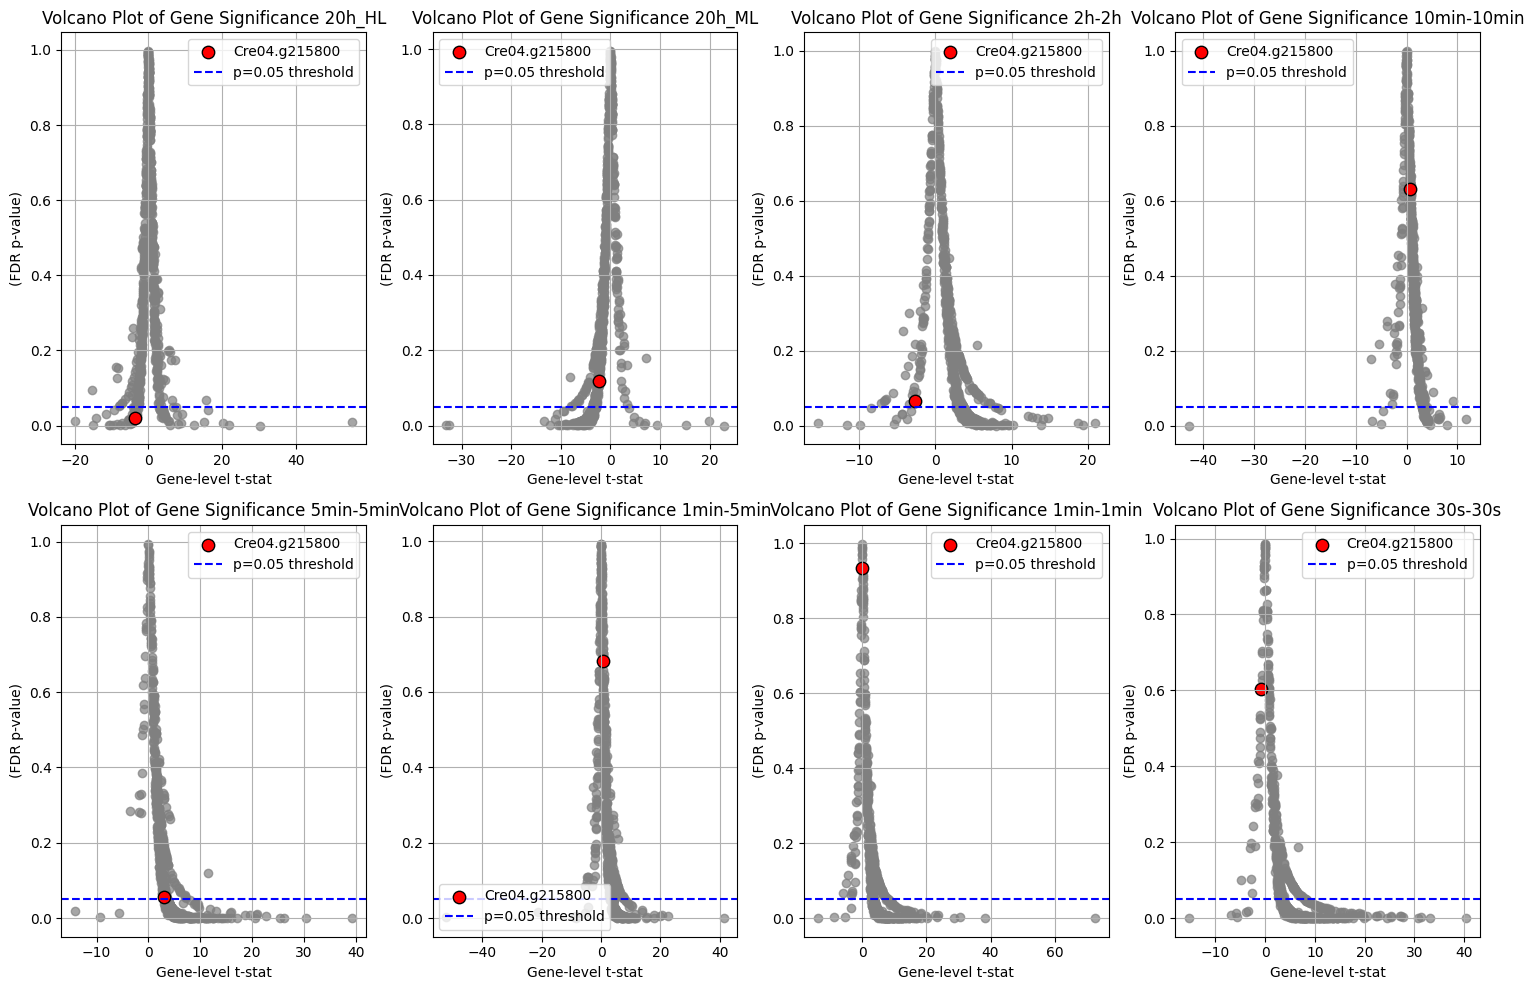

In [80]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

np.random.seed(42)
light_regimes = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '5min-5min', '1min-5min', '1min-1min', '30s-30s']
example_df = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/gene_level_ttest_pooled.csv')

n_cols = 4
n_rows = int(np.ceil(len(light_regimes) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows), squeeze=False)

for i, light in enumerate(light_regimes):
    row, col = divmod(i, n_cols)
    ax = axes[row][col]
    
    filtered_df = example_df[example_df['light_regime'] == light]
    filtered_df['combined_p'] = filtered_df['FDR']
    filtered_df['combined_z'] = filtered_df['t_stat']
    # filtered_df['neg_log10_p'] = filtered_df['combined_p']  # Garder les colonnes comme elles sont

    ax.scatter(filtered_df['combined_z'], filtered_df['combined_p'], alpha=0.7, color='gray')

    target_gene = 'Cre04.g215800'
    highlight = filtered_df[filtered_df['mutated_genes'] == target_gene]
    if not highlight.empty:
        ax.scatter(highlight['combined_z'], highlight['combined_p'], color='red', label=target_gene, s=80, edgecolors='black')

    ax.axhline((0.05), color='blue', linestyle='--', label='p=0.05 threshold')
    ax.set_xlabel('Gene-level t-stat')
    ax.set_ylabel('(FDR p-value)')
    ax.set_title(f'Volcano Plot of Gene Significance {light}')
    ax.legend()
    ax.grid(True)
for i in range(len(light_regimes), n_rows * n_cols):
    row, col = divmod(i, n_cols)
    fig.delaxes(axes[row][col])
plt.tight_layout()
plt.show()

preparing data to go plate randeff

In [79]:
import pandas as pd

# Load your data
data = pd.read_csv("/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/gene_level_ttest_pooled.csv")  # replace with your actual file path

# Clean
data = data[~data['FDR'].isna() & ~data['mutated_genes'].isna() & ~data['light_regime'].isna()]

# Step 1: Get genes with FDR < 0.05 in 20h_HL
hl_sig_genes = data[
    (data['light_regime'] == '20h_HL') & 
    (data['FDR'] < 0.05)
]['mutated_genes'].unique()

# Step 2: For these genes, check if they have FDR ≥ 0.05 in *all* other regimes
valid_genes = []

for gene in hl_sig_genes:
    gene_data = data[(data['mutated_genes'] == gene) & (data['light_regime'] != '20h_HL')]
    
    if all(gene_data['FDR'] >= 0.05):
        valid_genes.append(gene)

# Print results
print("Genes with FDR < 0.05 in 20h_HL and FDR ≥ 0.05 in all other regimes:")
print(valid_genes)


Genes with FDR < 0.05 in 20h_HL and FDR ≥ 0.05 in all other regimes:
['Cre02.g113500,Cre01.g034500', 'Cre04.g215800', 'Cre07.g325715,Cre11.g467566 & Cre11.g467567', 'Cre10.g431250,Cre07.g315850', 'Cre10.g453900,Cre01.g007700 & Cre01.g007737', 'Cre13.g589400,Cre13.g589350', 'Cre13.g591501', 'Cre14.g621800', 'Cre16.g688350', 'Cre17.g705750,Cre01.g003950']
